# Lekcja 15: Algebra liniowa w praktyce DS — Rozwiązania zadań

Pełne treści zadań + rozwiązania. Uruchom po przejściu lekcji.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy import stats
%matplotlib inline
np.random.seed(42)

iris   = load_iris()
X_iris = iris.data
y_iris = iris.target
print(f'Iris: {X_iris.shape} | cechy: {iris.feature_names}')

Iris: (150, 4) | cechy: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


---
## ✏️ Zadania podstawowe (1–8)

### ✏️ Zadanie 1 – Tworzenie i wizualizacja wektorów

Stwórz dwa wektory 2D: **v1 = [3, 4]** i **v2 = [1, 2]**.
Oblicz ich sumę, różnicę oraz narysuj wszystkie cztery wektory
na wykresie używając `plt.quiver()`.

**Wymagania:**
- Stwórz wektory jako NumPy arrays
- Oblicz `v1 + v2` i `v1 - v2`
- Narysuj wszystkie 4 wektory (v1, v2, suma, różnica) różnymi kolorami
- Dodaj legendę i grid

*(proste)*

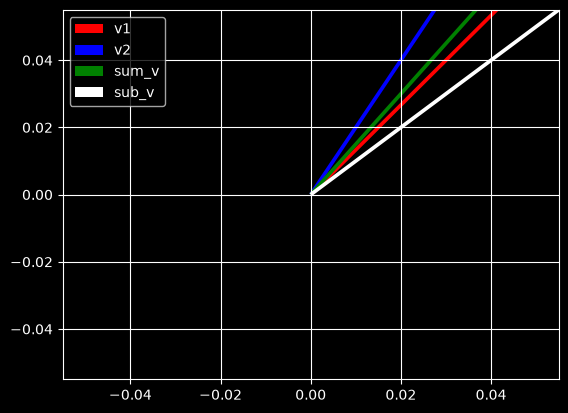

In [13]:
v1 = np.array([3, 4])
v2 = np.array([1, 2])

sum_v = v1 + v2
sub_v = v1 - v2

plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label='v2')
plt.quiver(0, 0, sum_v[0], sum_v[1], angles='xy', scale_units='xy', scale=1, color='g', label='sum_v')
plt.quiver(0, 0, sub_v[0], sub_v[1], angles='xy', scale_units='xy', scale=1, color='w', label='sub_v')
plt.grid()
plt.legend()


### ✏️ Zadanie 2 – Normalizacja Min-Max wektorów

Dla datasetu Iris, wybierz cechę **petal length** (kolumna 2).
Wykonaj normalizację Min-Max do przedziału [0, 1] używając operacji
wektorowych NumPy.

**Wymagania:**
- Wczytaj Iris, wybierz kolumnę 2
- Oblicz min i max
- Zastosuj wzór: `(x - min) / (max - min)`
- Wypisz pierwsze 10 wartości przed i po normalizacji
- Sprawdź, że min=0, max=1 po normalizacji

*(proste)*

In [14]:
petal_length = X_iris[:, 2]

min_val = np.min(petal_length)
max_val = np.max(petal_length)

normalized_petal_length = (petal_length - min_val) / (max_val - min_val)

print("Pierwsze 10 wartości przed normalizacją:", petal_length[:10])
print("min val:", min_val)
print("max val:", max_val)

Pierwsze 10 wartości przed normalizacją: [1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5]
min val: 1.0
max val: 6.9


### ✏️ Zadanie 3 – Iloczyn skalarny i kąt

Oblicz iloczyn skalarny dwóch wektorów **a = [1, 2, 3]** i **b = [4, 5, 6]**.
Następnie oblicz kąt między nimi w stopniach.

**Wymagania:**
- Użyj `np.dot()` lub operatora `@`
- Oblicz normy wektorów
- Użyj wzoru: `cos(θ) = (a·b) / (|a||b|)`
- Zamień radiany na stopnie

*(proste)*

In [6]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

iloczyn_skalarny = np.dot(a, b)

norma_a = np.linalg.norm(a)
norma_b = np.linalg.norm(b)

kat = np.arccos(iloczyn_skalarny / (norma_a * norma_b))
kat_stopnie = np.degrees(kat)

print("Iloczyn skalarny:", iloczyn_skalarny)
print("Kąt (stopnie):", kat_stopnie)

Iloczyn skalarny: 32
Kąt (stopnie): 12.933154491899135


### ✏️ Zadanie 4 – Transpozycja i reshape

Stwórz macierz 3×4 z liczbami od 1 do 12. Wykonaj transpozycję,
a następnie reshape do kształtu (2, 6) i (6, 2).

**Wymagania:**
- Użyj `np.arange()` i `.reshape()`
- Wyświetl macierz oryginalną, transponowaną i obie reshaped
- Sprawdź `.shape` każdej macierzy

*(proste)*

In [8]:
macierz = np.arange(1, 13).reshape(3, 4)
t_macierz = np.transpose(macierz)

reshape_1 = macierz.reshape(2, 6)
reshape_2 = t_macierz.reshape(2, 6)

print("Oryginalna:")
print(macierz)

print("\nTransponowana:")
print(t_macierz)

print("\nReshape oryginalnej:")
print(reshape_1)

print("\nReshape transponowanej:")
print(reshape_2)

print("\nKształty:")
print(macierz.shape)
print(t_macierz.shape)
print(reshape_1.shape)
print(reshape_2.shape)

Oryginalna:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Transponowana:
[[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]]

Reshape oryginalnej:
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]

Reshape transponowanej:
[[ 1  5  9  2  6 10]
 [ 3  7 11  4  8 12]]

Kształty:
(3, 4)
(4, 3)
(2, 6)
(2, 6)


### ✏️ Zadanie 5 – Macierz identyczności i diagonalna

Stwórz macierz identyczności 5×5. Następnie stwórz macierz diagonalną
z wartościami [1, 2, 3, 4, 5] na diagonali.

**Wymagania:**
- Użyj `np.eye()` i `np.diag()`
- Wyświetl obie macierze
- Sprawdź, że mnożenie macierzy przez identyczność daje tę samą macierz (`A @ I = A`)

*(proste)*

In [15]:
macierz = np.eye(5)
diagonalna = np.diag([1, 2, 3, 4, 5])

print("Macierz identyczności:")
print(macierz)

print("\nMacierz diagonalna:")
print(diagonalna)

print("\nMnożenie macierzy diagonalnej przez identyczność:")
print(diagonalna @ diagonalna)

Macierz identyczności:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

Macierz diagonalna:
[[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]

Mnożenie macierzy diagonalnej przez identyczność:
[[ 1  0  0  0  0]
 [ 0  4  0  0  0]
 [ 0  0  9  0  0]
 [ 0  0  0 16  0]
 [ 0  0  0  0 25]]


### ✏️ Zadanie 6 – Normy wektora

Dla wektora **v = [3, -4, 12, 0, -5]** oblicz normy L1, L2 i L∞.
Następnie znormalizuj wektor do jednostkowej długości (L2=1).

**Wymagania:**
- Użyj `np.linalg.norm()` z różnymi `ord`
- Oblicz `v_normalized = v / ‖v‖₂`
- Sprawdź normę znormalizowanego wektora (powinna być ≈ 1)

*(proste)*

### ✏️ Zadanie 7 – Odległość między obserwacjami

Z datasetu Iris wybierz pierwszą i ostatnią obserwację.
Oblicz odległość euklidesową i Manhattan między nimi.

**Wymagania:**
- Wybierz `X[0]` i `X[-1]`
- Oblicz różnicę wektorów
- Oblicz normę L2 różnicy (odległość euklidesowa)
- Oblicz normę L1 różnicy (odległość Manhattan)

*(proste)*

### ✏️ Zadanie 8 – Mnożenie macierzy i wektora

Stwórz macierz losową A o wymiarach 4×3 i wektor losowy w o wymiarach (3,).
Oblicz `y = A @ w`. Sprawdź kształt wyniku.

**Wymagania:**
- Użyj `np.random.randn()`
- Wykonaj mnożenie macierz @ wektor
- Wyświetl kształty: A, w, y
- Wyjaśnij, dlaczego wynik ma kształt (4,)

*(proste)*

---
## ✏️ Zadania średnie (9–12)

### ✏️ Zadanie 9 – Standaryzacja datasetu

Wczytaj cały dataset Iris (4 cechy). Zaimplementuj standaryzację (mean=0, std=1)
dla każdej cechy używając operacji NumPy. Porównaj wynik z `StandardScaler` ze sklearn.

**Wymagania:**
- Oblicz mean i std per kolumna (`axis=0`)
- Zastosuj wzór: `(X - mean) / std`
- Sprawdź mean i std po standaryzacji
- Porównaj z `sklearn.preprocessing.StandardScaler`
- Oblicz max różnicę między implementacjami

*(średnie)*

### ✏️ Zadanie 10 – Macierz odległości dla k-NN

Wybierz 10 losowych obserwacji z Iris. Oblicz pełną macierz odległości
euklidesowych (10×10) między wszystkimi parami. Wizualizuj jako heatmapę.

**Wymagania:**
- Losowo wybierz 10 obserwacji (użyj `np.random.choice` na indeksach)
- Użyj `euclidean_distances` z sklearn
- Wizualizuj macierz jako heatmapę (seaborn.heatmap lub plt.imshow)
- Diagonala powinna być 0

*(średnie)*

### ✏️ Zadanie 11 – Macierz kowariancji i korelacji

Dla datasetu Iris (4 cechy) oblicz macierz kowariancji i macierz korelacji.
Wizualizuj obie jako heatmapy. Zinterpretuj najsilniejszą korelację.

**Wymagania:**
- Oblicz macierz kowariancji: `np.cov(X, rowvar=False)`
- Oblicz macierz korelacji: `np.corrcoef(X, rowvar=False)` lub ręcznie
- Wizualizuj obie jako heatmapy z nazwami cech
- Znajdź parę cech o najwyższej korelacji (poza diagonalą)
- Narysuj scatter plot tej pary

*(średnie)*

### ✏️ Zadanie 12 – Regularyzacja L1 vs L2

Wygeneruj losowy wektor wag (20 elementów). Zasymuluj efekt regularyzacji
L1 (Lasso) i L2 (Ridge) dla różnych wartości λ = [0.01, 0.1, 1.0].
Narysuj wykres pokazujący jak liczba niezerowych wag zmienia się z λ dla L1.

**Wymagania:**
- Wygeneruj losowy wektor wag z rozkładu normalnego
- Dla L1: symuluj wyzerowanie wag poniżej `threshold = λ * k` (dobierz k)
- Dla L2: oblicz `penalty = λ * ||w||²`
- Narysuj liczbę niezerowych wag vs λ (tylko dla L1)
- Porównaj total penalty L1 vs L2 dla różnych λ

*(średnie)*

---
## 🧠 Zadania wyzwanie (13–20)

### 🧠 Zadanie 13 – Implementacja k-NN od zera

Zaimplementuj algorytm k-NN (k=5) od zera używając tylko NumPy
(bez `sklearn.neighbors`). Przetestuj na datasecie Iris z podziałem
train/test 80/20. Oblicz accuracy.

**Wymagania:**
- Podziel dane na train/test (użyj `sklearn.train_test_split`)
- Dla każdej obserwacji testowej:
  - Oblicz odległości do wszystkich train (pętla lub wektoryzacja)
  - Znajdź k=5 najbliższych sąsiadów
  - Voting: najczęstsza klasa (bincount)
- Oblicz accuracy: `(poprawne predykcje) / (total test)`
- Porównaj z `sklearn.neighbors.KNeighborsClassifier`

*(challenge)*

### 🧠 Zadanie 14 – PCA "ręcznie" — macierz kowariancji

Zaimplementuj pierwszą część PCA: oblicz macierz kowariancji dla datasetu Iris
i znajdź jej wartości własne (eigenvalues) oraz wektory własne (eigenvectors)
używając `np.linalg.eigh()`. Posortuj je malejąco. Narysuj wykres explained variance.

**Wymagania:**
- Wycentruj dane: `X_centered = X - X.mean(axis=0)`
- Oblicz macierz kowariancji: `Σ = X_centered.T @ X_centered / (n-1)`
- Znajdź eigenvalues i eigenvectors: `np.linalg.eigh(Σ)` (dla macierzy symetrycznych!)
- Posortuj malejąco według eigenvalues
- Oblicz explained variance ratio: `λᵢ / Σλᵢ`
- Narysuj wykres słupkowy explained variance per komponent
- Odpowiedź: ile komponentów pokrywa 95% wariancji?

*(challenge)*

### 🧠 Zadanie 15 – Projekcja danych na 2D (PCA kontynuacja)

Kontynuując zadanie 14, zredukuj dane Iris z 4D do 2D używając dwóch
pierwszych wektorów własnych. Narysuj scatter plot 2D z kolorami według klas.
Porównaj z `sklearn.decomposition.PCA`.

**Wymagania:**
- Użyj wyników z zadania 14 (eigenvectors)
- Weź 2 pierwsze wektory własne (kolumny) → macierz W (4, 2)
- Projektuj: `X_pca = X_centered @ W`
- Narysuj scatter plot, koloruj według y
- Porównaj z `sklearn.decomposition.PCA(n_components=2)`

*(challenge)*

### 🧠 Zadanie 16 – Cosine Similarity dla dokumentów

Stwórz 5 "dokumentów" reprezentowanych jako wektory TF (term frequency)
dla 10 słów. Oblicz macierz cosine similarity (5×5) między wszystkimi
dokumentami. Znajdź najbardziej podobną parę.

**Wymagania:**
- Stwórz losową macierz 5×10 (5 dokumentów, 10 słów), wartości całkowite 0-10
- Oblicz cosine similarity: `sim(a,b) = (a·b) / (||a|| ||b||)`
- Zaimplementuj funkcję `cosine_sim(v1, v2)` używając NumPy
- Oblicz pełną macierz 5×5 (lub sklearn.metrics.pairwise.cosine_similarity)
- Znajdź max similarity poza diagonalą

*(challenge)*

### 🧠 Zadanie 17 – Regresja liniowa — rozwiązanie analityczne

Dla prostego datasetu (1 cecha) zaimplementuj regresję liniową używając
wzoru normalnego: **w = (X^T X)^(-1) X^T y**. Porównaj z
`sklearn.linear_model.LinearRegression`.

**Dataset:** `X = np.linspace(0, 10, 100)`, `y = 2*X + 3 + szum`

**Wymagania:**
- Dodaj kolumnę jedynek do X (bias term) → `X_extended (100, 2)`
- Oblicz: `w = (X^T X)^(-1) X^T y` używając `np.linalg.inv()` i `@`
- Wyciągnij slope i intercept z w
- Porównaj ze sklearn.LinearRegression
- Narysuj: dane, własna linia, sklearn linia
- Oblicz MSE dla obu

*(challenge)*

### 🧠 Zadanie 18 – Broadcasting w praktyce — normalizacja grupowa

Dla datasetu Titanic, znormalizuj cechę **Fare** (opłata) osobno dla każdej
klasy kajuty (Pclass = 1, 2, 3) używając broadcastingu NumPy.

**Wymagania:**
- Wczytaj Titanic, wybierz kolumny Fare i Pclass
- Usuń brakujące wartości w Fare
- Dla każdego Pclass oblicz mean i std, zastosuj standaryzację
- Sprawdź, że każda grupa ma mean≈0, std≈1 po normalizacji
- Histogram przed i po normalizacji

*(challenge)*

### 🧠 Zadanie 19 – SVD dla kompresji obrazu

Użyj SVD (Singular Value Decomposition) do kompresji macierzy obrazu
grayscale. Zachowaj k=10, 20, 50 największych wartości singularnych.
Porównaj wizualnie i oblicz compression ratio.

**Wymagania:**
- Stwórz syntetyczny obraz grayscale (macierz)
  lub wczytaj: `scipy.datasets.face(gray=True)`
- Wykonaj SVD: `U, S, Vt = np.linalg.svd(image, full_matrices=False)`
- Rekonstrukcja: `image_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]`
- Dla k = [10, 20, 50, pełne]: narysuj obraz i oblicz MSE

*(challenge)*

### 🧠 Zadanie 20 – Gradient Descent wizualizacja

Zaimplementuj prosty gradient descent dla funkcji kwadratowej
**f(x) = (x − 3)² + 5**. Wizualizuj trajektorię optymizacji.

**Wymagania:**
- Funkcja: `f(x) = (x - 3)² + 5`
- Gradient: `f'(x) = 2(x - 3)`
- Start: `x = -2`, learning rate `α = 0.1`, iteracje: 20
- W każdej iteracji: `x_new = x - α * f'(x)`
- Zapisz trajektorię (x, f(x)) dla każdej iteracji
- Narysuj funkcję f(x) dla x ∈ [−3, 7] z trajektorią
- Oblicz x końcowe (powinno być ≈ 3)

*(challenge)*